# Libraries

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# scaling numerical data
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# encoding non-numerival data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Read Dataset

In [15]:
filepath = '/content/drive/MyDrive/Datasets/House_Pricing_Case_Study.csv'
df_house_price = pd.read_csv(filepath)
df_house_price.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

## Dataset Overview


In [17]:
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [18]:
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [19]:
for i in df_house_price.columns:
  print(df_house_price[i].value_counts())

ID
795000620     3
7520000695    2
7200179       2
3904100089    2
6308000010    2
             ..
5602000275    1
1786200010    1
1525079069    1
126049167     1
1211000185    1
Name: count, Length: 21436, dtype: int64
Date House was Sold
15 April 2016        2231
14 July 2017         2211
14 June 2017         2180
14 August 2017       1940
14 October 2017      1878
15 March 2016        1875
14 September 2017    1774
14 May 2017          1768
14 December 2017     1471
14 November 2017     1411
15 February 2016     1250
15 January 2016       978
15 May 2016           646
Name: count, dtype: int64
Sale Price
350000.0    172
450000.0    171
550000.0    159
500000.0    152
425000.0    150
           ... 
357186.0      1
747450.0      1
589999.0      1
402723.0      1
999999.0      1
Name: count, Length: 3625, dtype: int64
No of Bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count

In [20]:
for i in df_house_price.columns:
  print(df_house_price[i].unique)

<bound method Series.unique of 0        7129300520
1        6414100192
2        5631500400
3        2487200875
4        1954400510
            ...    
21608     263000018
21609    6600060120
21610    1523300141
21611     291310100
21612    1523300157
Name: ID, Length: 21613, dtype: int64>
<bound method Series.unique of 0         14 October 2017
1        14 December 2017
2        15 February 2016
3        14 December 2017
4        15 February 2016
               ...       
21608         14 May 2017
21609    15 February 2016
21610        14 June 2017
21611     15 January 2016
21612     14 October 2017
Name: Date House was Sold, Length: 21613, dtype: object>
<bound method Series.unique of 0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: Sale Price, Length: 21613, dtype: float64>
<bound method Series.unique of 0        3
1        3
2    

In [21]:
df_house_price.shape

(21613, 21)

## Missing Values

In [22]:
df_house_price.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [24]:
# Based on the missing value counts ['No of Times Visited'] - 19489/21613  values are missing so, drop this column
df_house_price.drop(columns=['No of Times Visited'], axis=1, inplace=True)

In [25]:
df_house_price.shape

(21613, 20)

In [26]:
# Target column 'Sale Price' has 4 missing values. It shouldn't be replaced, so we can remove the rows

# Filtering the null values in target column
df_house_price[df_house_price['Sale Price'].isna()]

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
90,2791500270,14 May 2017,NaN,4,2.5,1980.0,7403.0,2.0,No,Fair,7,1980.0,0,30,0,98023.0,47.2897,-122.372,1980.0,7510
168,3261020370,14 June 2017,NaN,3,2.5,2680.0,9750.0,1.0,No,Good,8,1610.0,1070,39,0,98034.0,47.7028,-122.231,2480.0,8750
21456,3362401761,15 February 2016,NaN,2,1.5,1020.0,1049.0,3.0,No,Fair,8,1020.0,0,10,0,98103.0,47.6800,-122.348,1350.0,1395
21522,603000555,15 March 2016,NaN,6,3.0,2390.0,4000.0,2.0,No,Fair,7,2390.0,0,4,0,98118.0,47.5173,-122.286,1680.0,5000


In [27]:
# before dropping
df_house_price.shape

(21613, 20)

In [28]:
df_house_price.dropna(subset=['Sale Price'], inplace=True)

In [29]:
# after dropping
df_house_price.shape

(21609, 20)

In [30]:
# Removing the rows which contain missing values from the below feature columns
df_house_price.dropna(subset=['Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)'], inplace=True)

In [31]:
df_house_price.shape

(21605, 20)

<Axes: xlabel='Flat Area (in Sqft)', ylabel='Count'>

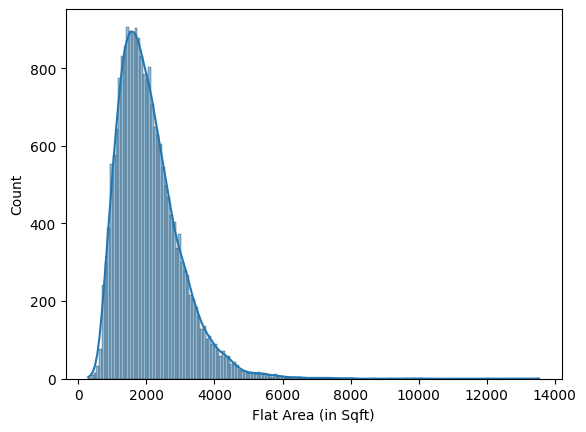

In [32]:
sns.histplot(df_house_price['Flat Area (in Sqft)'], kde=True)

<Axes: xlabel='Lot Area (in Sqft)', ylabel='Count'>

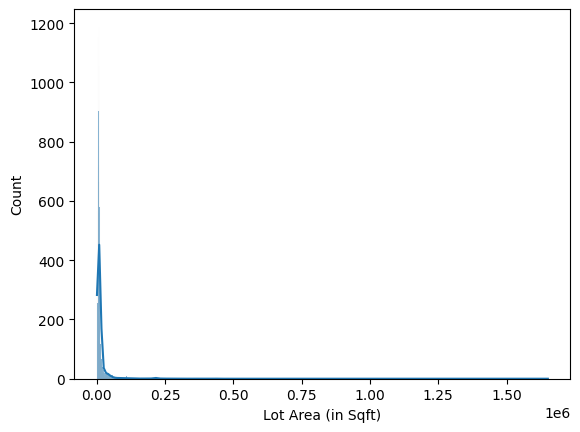

In [33]:
sns.histplot(df_house_price['Lot Area (in Sqft)'], kde=True)

<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Count'>

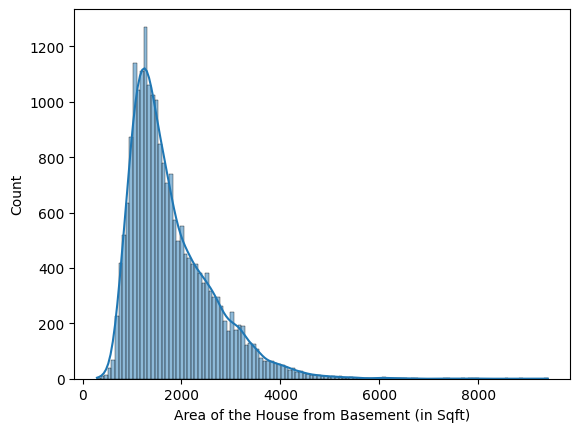

In [34]:
sns.histplot(df_house_price['Area of the House from Basement (in Sqft)'], kde=True)

In [35]:
# All numerical columns are having right skewed plots, so for imputation of missing values median is used.
df_house_price['Flat Area (in Sqft)'] = df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median())
df_house_price['Lot Area (in Sqft)'] = df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median())
df_house_price['Area of the House from Basement (in Sqft)'] = df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median())

In [36]:
# 'No of Bathrooms' is a categorial column, so for imputation mode is used
df_house_price['No of Bathrooms'] = df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].mode()[0])

In [37]:
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [38]:
# Duplicates
df_house_price.duplicated().sum()

np.int64(0)

## Outliers handling

In [39]:
num_cols = []
cat_cols = []


In [40]:
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160500e+04,2.160500e+04,21605.000000,21605.000000,21605.000000,2.160500e+04,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000
mean,4.580367e+09,5.402050e+05,3.370840,2.114742,2079.941032,1.510820e+04,1.494237,7.623513,1788.388243,291.513307,46.994214,84.340338,98077.939088,47.560033,-122.213876,1986.590558,12771.120065
std,2.876596e+09,3.674205e+05,0.929939,0.770125,918.393347,4.142714e+04,0.539927,1.105600,827.997287,442.589231,29.367378,401.536399,53.508573,0.138561,0.140831,685.475040,27308.853462
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.215000e+05,3.000000,1.750000,1430.000000,5.042000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470900,-122.328000,1490.000000,5100.000000
50%,3.904931e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10086.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [41]:

num_cols = df_house_price.drop(columns=['ID']).select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_house_price.select_dtypes(include=['object', 'bool']).columns


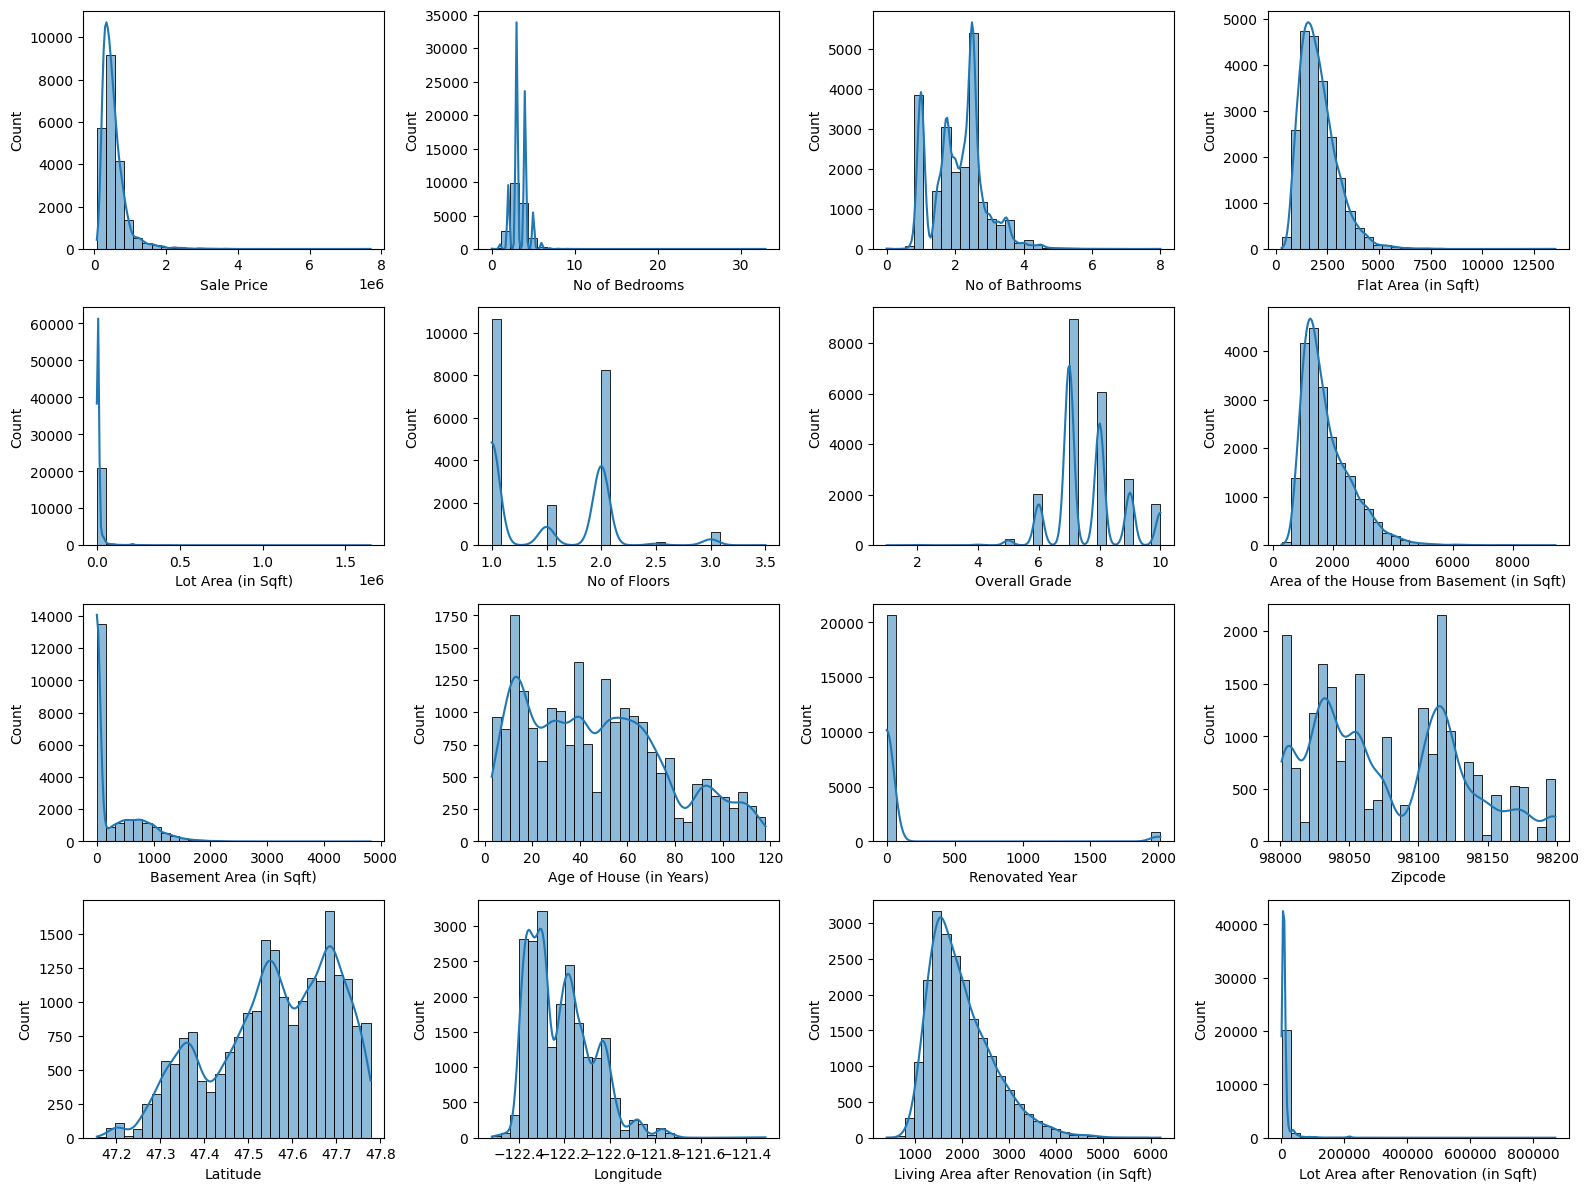

In [42]:
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.histplot(df_house_price[num_cols[i]], kde=True, bins = 30)
plt.tight_layout()
plt.show()

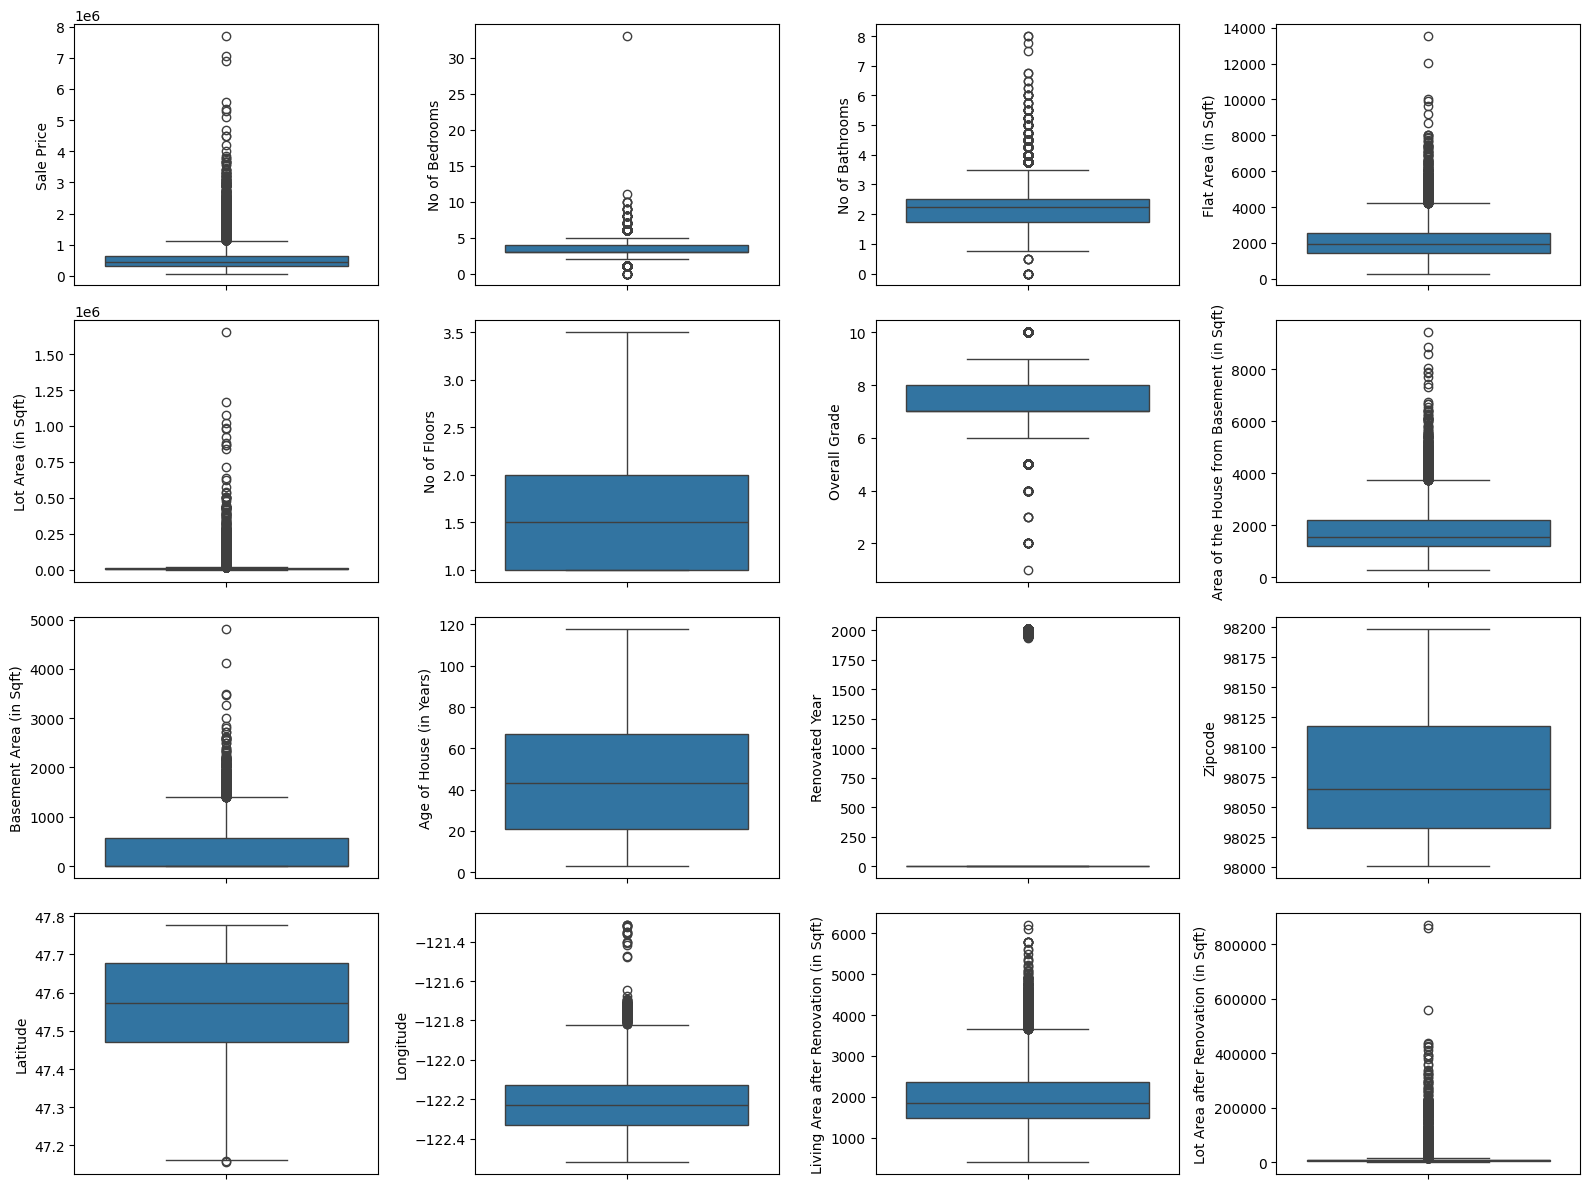

In [43]:
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.boxplot(df_house_price[num_cols[i]])
plt.tight_layout()
plt.show()

In [44]:
df_house_price[num_cols].columns.tolist()

['Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [45]:
# outlier_cols = [
#     'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
#     'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
#     'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']

In [46]:
# for i in outlier_cols:
#   Q1 = df_house_price[i].quantile(0.25)
#   Q3 = df_house_price[i].quantile(0.75)
#   IQR = Q3 - Q1

#   lower_bound = Q1 - 1.5 * IQR
#   upper_bound = Q3 + 1.5 * IQR

#   # Cap the outliers at the upper and lower bound
#   outliers = df_house_price[(df_house_price[i]<lower_bound) | (df_house_price[i]>upper_bound)]
# print(outliers)
# len(outliers)


In [47]:
# before clipping
df_house_price['No of Bedrooms'].unique()

array([ 3,  2,  4,  5,  1,  6,  7,  0,  8,  9, 11, 10, 33])

In [48]:
# no of Bedrooms have value 33 extremely distant from other values.
df_house_price['No of Bedrooms'] = df_house_price['No of Bedrooms'].clip(upper=11)

In [49]:
# Afterv clipping
df_house_price['No of Bedrooms'].unique()

array([ 3,  2,  4,  5,  1,  6,  7,  0,  8,  9, 11, 10])

In [50]:
# 'Lot Area (in Sqft)' is extremely right skewed with long tail

df_house_price['Lot Area (in Sqft)'] = np.log(df_house_price['Lot Area (in Sqft)'])

In [51]:
# 'Lot Area after Renovation (in Sqft)' is extremely right skewed with long tail

df_house_price['Lot Area after Renovation (in Sqft)'] = np.log(df_house_price['Lot Area after Renovation (in Sqft)'])

In [52]:
df_house_price['Flat Area (in Sqft)'].value_counts()

,count
Flat Area (in Sqft),
1300.0,138
1400.0,135
1440.0,133
1800.0,129
1010.0,129
...,...
2507.0,1
9890.0,1
5584.0,1


In [53]:
#In Flat Area (in Sqft), there is only two columns which are outliers. Hence clipping the two highest observations to 3rd lrgest observation

third_large_flat  = df_house_price['Flat Area (in Sqft)'].nlargest(3) # calculating third largest value of Flat Area (in Sqft)
print(third_large_flat)
# df_house_price['Flat Area (in Sqft)'] = df_house_price['Flat Area (in Sqft)'].clip(upper = third_large_flat) # clipping by third largest value
# sns.boxplot(df_house_price['Flat Area (in Sqft)'])

12777    13540.0
7252     12050.0
3914     10040.0
Name: Flat Area (in Sqft), dtype: float64


In [54]:
df_house_price['Flat Area (in Sqft)'] = df_house_price['Flat Area (in Sqft)'].clip(upper = 10040) # clipping by third largest value


<Axes: ylabel='Flat Area (in Sqft)'>

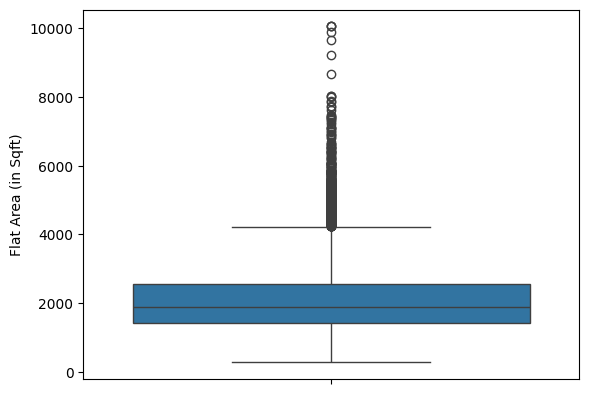

In [55]:
sns.boxplot(df_house_price['Flat Area (in Sqft)'])

# Scaling

In [56]:
# Before minmax scaling
df_house_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,8.639411,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,8.639411
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,8.887653,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,8.941022
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,9.210340,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8.994917
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,8.517193,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,8.517193
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8.997147,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,8.923058


# Scaling

In [57]:
print(num_cols)

print(cat_cols)

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [58]:
num_cols = num_cols.drop(['Zipcode', 'Longitude', 'Latitude'])

In [59]:
# Convert 'Date House was Sold' to datetime and extract the year as a number
df_house_price['Year_Sold'] = pd.to_datetime(df_house_price['Date House was Sold']).dt.year

# Drop the old text column so it doesn't interfere with encoding later
df_house_price.drop(columns=['Date House was Sold'], inplace=True)

In [60]:
# All numerical columns are right skewed, so we can apply minmax scaler for all numerical columns.
num_cols = df_house_price.select_dtypes(include=['int64', 'float64']).columns

# Exclude the target variable
num_cols = num_cols.drop('Sale Price')

minmaxscaler = MinMaxScaler()

df_house_price[num_cols] = minmaxscaler.fit_transform(df_house_price[num_cols])

In [61]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

# Encoding

In [62]:
ohe_cols = ['Waterfront View', 'Condition of the House']

# creating object
ohe_obj = OneHotEncoder(sparse_output=False)

encoded_data = ohe_obj.fit_transform(df_house_price[ohe_cols])

encoded_cols = ohe_obj.get_feature_names_out(ohe_cols)   # Getting the unique() of the values in ohe_cools using ohe_obj().func()

encoded_df = pd.DataFrame(encoded_data, columns = encoded_cols, index=df_house_price.index)

encoded_df.head()

,Waterfront View_No,Waterfront View_Yes,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [63]:
print(encoded_data)
encoded_cols

[[1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 ...
 [1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]]


array(['Waterfront View_No', 'Waterfront View_Yes',
       'Condition of the House_Bad', 'Condition of the House_Excellent',
       'Condition of the House_Fair', 'Condition of the House_Good',
       'Condition of the House_Okay'], dtype=object)

In [64]:
df_house_price.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold
0,0.720103,221900.0,0.272727,0.12500,0.091282,0.295858,0.0,No,Fair,0.666667,0.097588,0.000000,0.521739,0.000000,0.893939,0.571498,0.217608,0.161934,0.300162,2017
1,0.647853,538000.0,0.272727,0.28125,0.233846,0.326644,0.4,No,Fair,0.666667,0.206140,0.082988,0.556522,0.988089,0.626263,0.908959,0.166113,0.222165,0.342058,2017
2,0.568795,180000.0,0.181818,0.12500,0.049231,0.366664,0.0,No,Fair,0.555556,0.052632,0.000000,0.713043,0.000000,0.136364,0.936143,0.237542,0.399415,0.349544,2016
3,0.251157,604000.0,0.363636,0.37500,0.171282,0.280700,0.0,No,Excellent,0.666667,0.083333,0.188797,0.434783,0.000000,0.681818,0.586939,0.104651,0.165376,0.283185,2017
4,0.197333,510000.0,0.272727,0.25000,0.142564,0.340224,0.0,No,Fair,0.777778,0.152412,0.000000,0.243478,0.000000,0.368687,0.741354,0.393688,0.241094,0.339562,2016


In [65]:
# Dropping the original cat cols from original df and then Concatenating the encoded_df to the original df

df_ohe_2 = pd.concat([df_house_price.drop(columns = ohe_cols), encoded_df], axis=1)
df_ohe_2.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold,Waterfront View_No,Waterfront View_Yes,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,0.720103,221900.0,0.272727,0.12500,0.091282,0.295858,0.0,0.666667,0.097588,0.000000,...,0.161934,0.300162,2017,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.647853,538000.0,0.272727,0.28125,0.233846,0.326644,0.4,0.666667,0.206140,0.082988,...,0.222165,0.342058,2017,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.568795,180000.0,0.181818,0.12500,0.049231,0.366664,0.0,0.555556,0.052632,0.000000,...,0.399415,0.349544,2016,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.251157,604000.0,0.363636,0.37500,0.171282,0.280700,0.0,0.666667,0.083333,0.188797,...,0.165376,0.283185,2017,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.197333,510000.0,0.272727,0.25000,0.142564,0.340224,0.0,0.777778,0.152412,0.000000,...,0.241094,0.339562,2016,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [66]:
df_house_price.shape

(21605, 20)